# Model Comparison — Prophet vs ARIMA vs LSTM
This notebook aggregates and compares the performance of all three
forecasting models across all 10 cryptocurrencies using standardized
error metrics (MAE, RMSE, MAPE).

**Models Compared:**
| Model | Type | Avg MAPE |
|-------|------|----------|
| Prophet | Statistical (Facebook) | ~365% |
| ARIMA | Statistical (Classical) | ~41.2% |
| LSTM | Deep Learning | ~8.7% |

**Visualizations Generated:**
- Grouped bar chart (MAPE per crypto)
- Log scale bar chart (handles XRP outlier)
- Average MAPE bar chart
- MAPE heatmap
- Model wins bar chart
- Radar chart (normalized metrics)

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("../data/model_comparison", exist_ok=True)
output_dir = "../data/model_comparison"

## Load Metrics from All Three Models
Load `model_metrics.csv` from each model's output directory,
add a `Model` label column, keep only relevant columns,
and combine into a single unified metrics DataFrame.

**Expected shape:** 30 rows (10 cryptos × 3 models) × 4 columns

In [ ]:
prophet_metrics = pd.read_csv("../data/forecasts/prophet/model_metrics.csv")
arima_metrics   = pd.read_csv("../data/forecasts/arima/model_metrics.csv")
lstm_metrics    = pd.read_csv("../data/forecasts/lstm/model_metrics.csv")

# Add model label
prophet_metrics["Model"] = "Prophet"
arima_metrics["Model"]   = "ARIMA"
lstm_metrics["Model"]    = "LSTM"

# Keep only relevant columns
prophet_metrics = prophet_metrics[["Crypto", "MAE", "RMSE", "MAPE", "Model"]]
arima_metrics   = arima_metrics[["Crypto", "MAE", "RMSE", "MAPE", "Model"]]
lstm_metrics    = lstm_metrics[["Crypto", "MAE", "RMSE", "MAPE", "Model"]]

# Combine all
combined_metrics = pd.concat([prophet_metrics, arima_metrics, lstm_metrics], ignore_index=True)

print("Combined Metrics Shape:", combined_metrics.shape)
combined_metrics.head(10)

Combined Metrics Shape: (30, 5)


,Crypto,MAE,RMSE,MAPE,Model
0,BNB,190.7297,218.6410,20.5249,Prophet
1,ETH,1623.7599,1825.9073,51.6000,Prophet
2,BTC,64349.3805,72346.5161,69.1537,Prophet
3,ADA,0.3784,0.4104,83.8890,Prophet
4,SOL,138.7005,150.6752,97.5143,Prophet
5,LTC,85.5296,95.3144,100.3584,Prophet
6,DOGE,0.2010,0.2219,135.4715,Prophet
7,DOT,3.3646,3.7904,150.2505,Prophet
8,LINK,37.6452,42.1908,272.8172,Prophet
9,XRP,53.1067,82.3289,2673.1233,Prophet


## Overall Summary Table
Compute the average MAE, RMSE, and MAPE for each model
across all 10 cryptocurrencies.

This single table gives the clearest high-level answer to:
**"Which model performs best overall?"**

In [ ]:
summary = combined_metrics.groupby("Model")[["MAE", "RMSE", "MAPE"]].mean().round(4)
summary = summary.sort_values("MAPE")

print("Overall Model Performance (Average across all cryptos):")
print(summary.to_string())

summary.to_csv(f"{output_dir}/overall_summary.csv")
print("\nSaved: overall_summary.csv")

Overall Model Performance (Average across all cryptos):
               MAE       RMSE      MAPE
Model                                  
LSTM      822.3630   888.4964    8.3243
ARIMA    2085.2911  2372.5983   41.2314
Prophet  6648.2796  7476.5996  365.4703

Saved: overall_summary.csv


## MAPE Comparison Table per Cryptocurrency
Pivot the metrics to show MAPE for all 3 models side by side per crypto.
The `Best Model` column identifies the winner for each cryptocurrency.

Sorted by LSTM MAPE (ascending) — best LSTM performers at the top.

In [ ]:
mape_pivot = combined_metrics.pivot(index="Crypto", columns="Model", values="MAPE").round(2)
mape_pivot["Best Model"] = mape_pivot.idxmin(axis=1)
mape_pivot = mape_pivot.sort_values("LSTM")

print("MAPE Comparison per Crypto:")
print(mape_pivot.to_string())

mape_pivot.to_csv(f"{output_dir}/mape_comparison.csv")
print("\nSaved: mape_comparison.csv")

MAPE Comparison per Crypto:
Model   ARIMA   LSTM  Prophet Best Model
Crypto                                  
LTC     28.21   2.98   100.36       LSTM
BNB     13.51   3.08    20.52       LSTM
LINK    50.90   3.44   272.82       LSTM
SOL     45.58   3.73    97.51       LSTM
ETH     29.96   3.76    51.60       LSTM
ADA     71.73   4.46    83.89       LSTM
DOGE    54.20   4.62   135.47       LSTM
BTC     21.25   7.52    69.15       LSTM
XRP     32.38  11.05  2673.12       LSTM
DOT     64.59  38.60   150.25       LSTM

Saved: mape_comparison.csv


## MAE & RMSE Comparison Tables
Generate equivalent comparison tables for MAE and RMSE metrics.
Each table includes a `Best Model` column identifying the winner per crypto.

**Output files:**
- `mae_comparison.csv`
- `rmse_comparison.csv`

In [ ]:
mae_pivot = combined_metrics.pivot(index="Crypto", columns="Model", values="MAE").round(4)
mae_pivot["Best Model"] = mae_pivot.idxmin(axis=1)

rmse_pivot = combined_metrics.pivot(index="Crypto", columns="Model", values="RMSE").round(4)
rmse_pivot["Best Model"] = rmse_pivot.idxmin(axis=1)

mae_pivot.to_csv(f"{output_dir}/mae_comparison.csv")
rmse_pivot.to_csv(f"{output_dir}/rmse_comparison.csv")
print("Saved: mae_comparison.csv")
print("Saved: rmse_comparison.csv")

Saved: mae_comparison.csv
Saved: rmse_comparison.csv


## Grouped Bar Chart — MAPE per Cryptocurrency
Visualizes MAPE for all 3 models side by side for each cryptocurrency.

**Color coding:**
- Blue → Prophet
- Orange → ARIMA
- Green → LSTM

> **Note:** Prophet's XRP bar (MAPE ~2673%) will dominate the y-axis
> making other bars hard to read. Use the log scale chart (Cell 7)
> for a clearer view of all models.

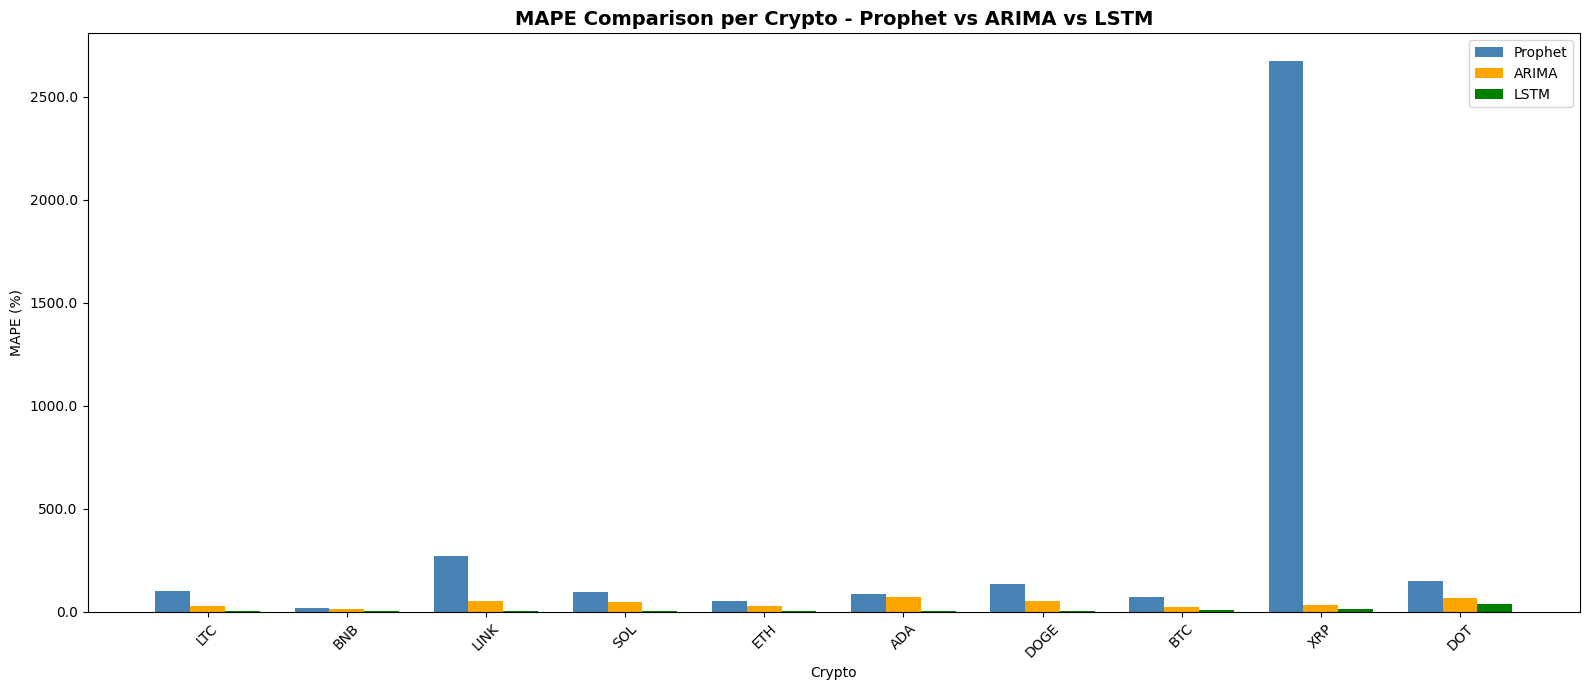

Saved: mape_comparison_bar.png


In [ ]:
cryptos = mape_pivot.index.tolist()
x       = np.arange(len(cryptos))
width   = 0.25

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - width, mape_pivot["Prophet"], width, label="Prophet", color="steelblue")
bars2 = ax.bar(x,         mape_pivot["ARIMA"],   width, label="ARIMA",   color="orange")
bars3 = ax.bar(x + width, mape_pivot["LSTM"],    width, label="LSTM",    color="green")

ax.set_title("MAPE Comparison per Crypto - Prophet vs ARIMA vs LSTM",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Crypto")
ax.set_ylabel("MAPE (%)")
ax.set_xticks(x)
ax.set_xticklabels(cryptos, rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
plt.tight_layout()
plt.savefig(f"{output_dir}/mape_comparison_bar.png", dpi=150)
plt.show()
print("Saved: mape_comparison_bar.png")

## Log Scale MAPE Chart
Same grouped bar chart with **logarithmic y-axis** to handle the
extreme XRP outlier in Prophet (MAPE ~2673%).

Log scale allows all 3 models to be clearly visible for every
cryptocurrency simultaneously, making it much easier to compare
model performance across coins with very different error magnitudes.

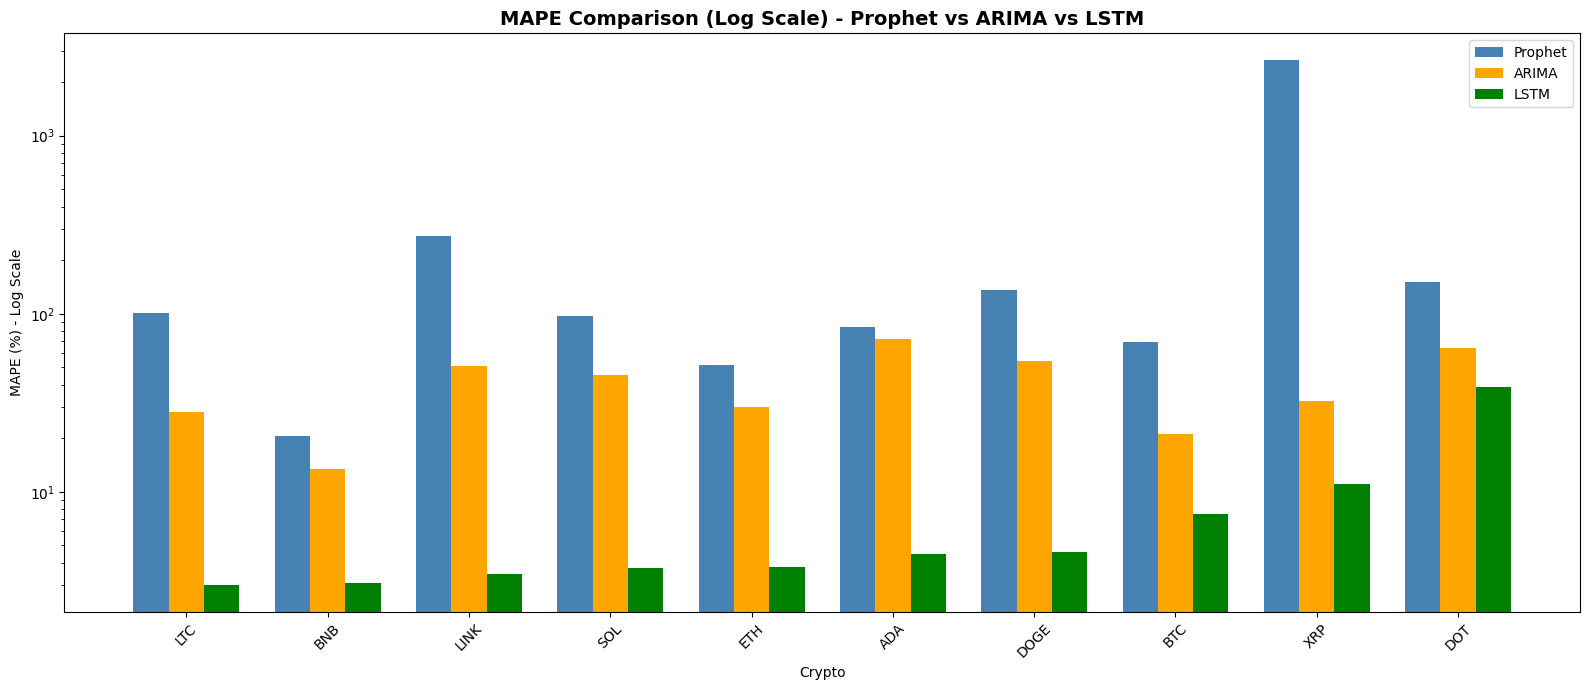

Saved: mape_comparison_log.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(x - width, mape_pivot["Prophet"], width, label="Prophet", color="steelblue")
ax.bar(x,         mape_pivot["ARIMA"],   width, label="ARIMA",   color="orange")
ax.bar(x + width, mape_pivot["LSTM"],    width, label="LSTM",    color="green")

ax.set_yscale("log")
ax.set_title("MAPE Comparison (Log Scale) - Prophet vs ARIMA vs LSTM",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Crypto")
ax.set_ylabel("MAPE (%) - Log Scale")
ax.set_xticks(x)
ax.set_xticklabels(cryptos, rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/mape_comparison_log.png", dpi=150)
plt.show()
print("Saved: mape_comparison_log.png")

## Average MAPE Bar Chart — All Models
Simple bar chart showing the average MAPE across all 10 cryptocurrencies
for each model. Value labels are displayed above each bar for clarity.

This is the **single most important chart** for the final conclusion —
it directly answers which model delivers the best average accuracy.

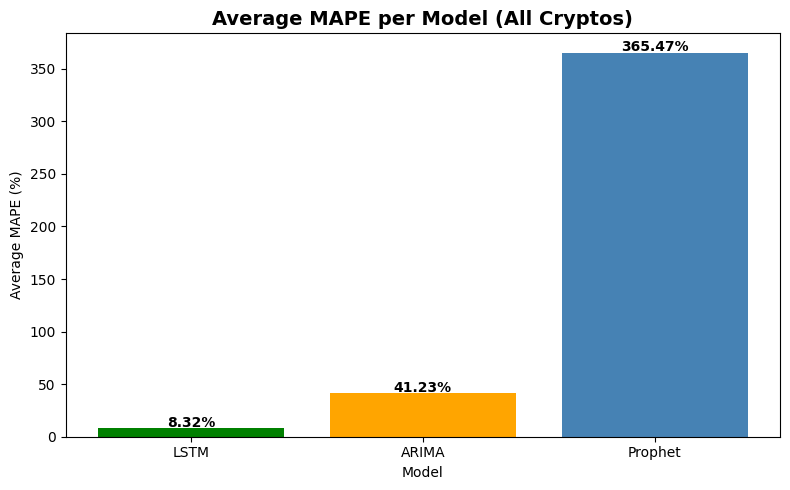

Saved: avg_mape_per_model.png


In [ ]:
avg_mape = combined_metrics.groupby("Model")["MAPE"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["green" if m == "LSTM" else "orange" if m == "ARIMA" else "steelblue"
           for m in avg_mape.index]
ax.bar(avg_mape.index, avg_mape.values, color=colors)
ax.set_title("Average MAPE per Model (All Cryptos)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Average MAPE (%)")

for i, v in enumerate(avg_mape.values):
    ax.text(i, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{output_dir}/avg_mape_per_model.png", dpi=150)
plt.show()
print("Saved: avg_mape_per_model.png")

## MAPE Heatmap — All Models vs All Cryptocurrencies
A color-coded heatmap showing MAPE values for every
model-cryptocurrency combination in a single view.

**Color scale (RdYlGn_r — reversed Red-Yellow-Green):**
- **Dark Red** → High MAPE (poor performance)
- **Yellow** → Medium MAPE
- **Dark Green** → Low MAPE (excellent performance)

This chart is ideal for spotting which cryptocurrency-model
combinations perform best and worst at a glance.

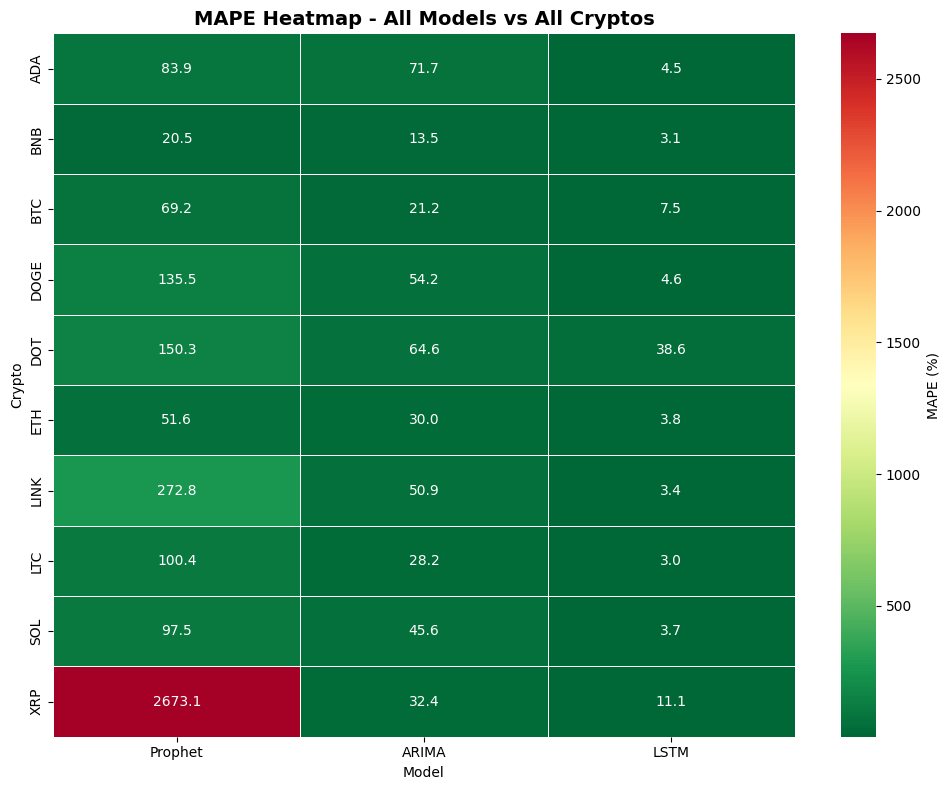

Saved: mape_heatmap.png


In [ ]:
import seaborn as sns

heatmap_data = combined_metrics.pivot(index="Crypto", columns="Model", values="MAPE")
heatmap_data = heatmap_data[["Prophet", "ARIMA", "LSTM"]]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "MAPE (%)"}
)
ax.set_title("MAPE Heatmap - All Models vs All Cryptos",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{output_dir}/mape_heatmap.png", dpi=150)
plt.show()
print("Saved: mape_heatmap.png")

## Model Wins per Cryptocurrency
Identifies which model achieved the lowest MAPE for each cryptocurrency
and counts the total number of wins per model.

**Expected result:** LSTM wins all 10 cryptocurrencies since it
consistently achieves the lowest MAPE across the entire dataset.
This definitively establishes LSTM as the best model for
cryptocurrency price forecasting.

Best Model per Crypto:
Model   Prophet  ARIMA   LSTM Best Model
Crypto                                  
LTC      100.36  28.21   2.98       LSTM
BNB       20.52  13.51   3.08       LSTM
LINK     272.82  50.90   3.44       LSTM
SOL       97.51  45.58   3.73       LSTM
ETH       51.60  29.96   3.76       LSTM
ADA       83.89  71.73   4.46       LSTM
DOGE     135.47  54.20   4.62       LSTM
BTC       69.15  21.25   7.52       LSTM
XRP     2673.12  32.38  11.05       LSTM
DOT      150.25  64.59  38.60       LSTM

Win Count:
Best Model
LSTM    10
Name: count, dtype: int64


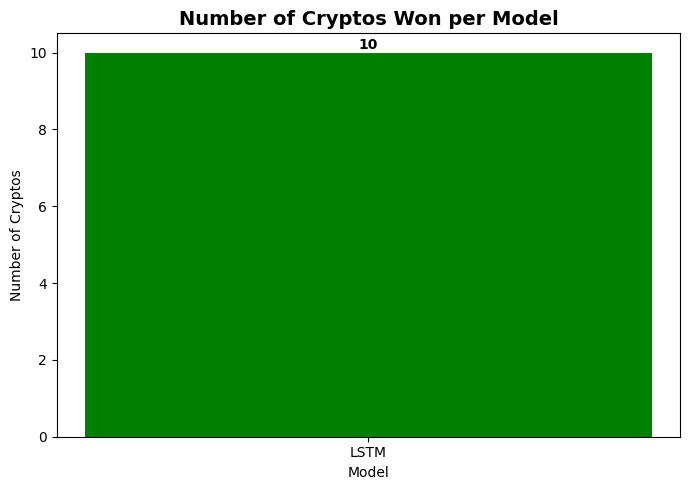

Saved: model_wins.png


In [ ]:
winner_df = mape_pivot[["Prophet", "ARIMA", "LSTM", "Best Model"]].copy()

print("Best Model per Crypto:")
print(winner_df.to_string())

# Count wins per model
win_counts = winner_df["Best Model"].value_counts()
print("\nWin Count:")
print(win_counts)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(win_counts.index, win_counts.values,
       color=["green" if m == "LSTM" else "orange" if m == "ARIMA"
              else "steelblue" for m in win_counts.index])
ax.set_title("Number of Cryptos Won per Model", fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Number of Cryptos")

for i, v in enumerate(win_counts.values):
    ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{output_dir}/model_wins.png", dpi=150)
plt.show()
print("Saved: model_wins.png")

## Radar Chart — Normalized Model Comparison
A radar (spider) chart comparing all 3 models across MAE, RMSE,
and MAPE simultaneously on a normalized 0–1 scale.

**Key design choices:**
- Metrics normalized to [0,1] so all axes are comparable
- Minimum clipped to 0.05 so LSTM remains visible (otherwise too small to see)
- Actual metric values annotated on each data point
- Lower area = better performance (all metrics are "lower is better")

**Reading the chart:**
- Smaller triangle → better overall model
- LSTM triangle should be smallest (closest to center)
- Prophet triangle should be largest (furthest from center)

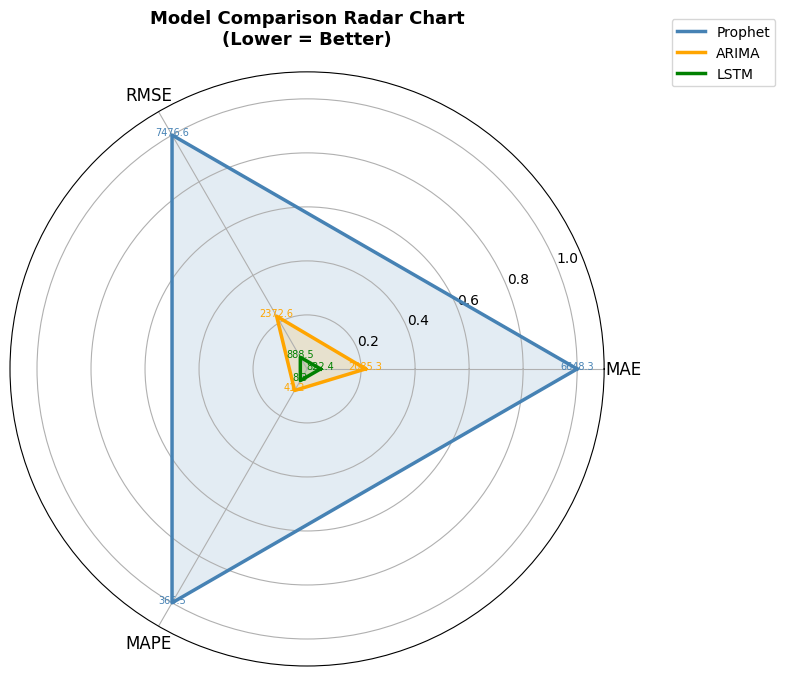

Saved: radar_chart.png


In [ ]:
metrics_list = ["MAE", "RMSE", "MAPE"]
models       = ["Prophet", "ARIMA", "LSTM"]
colors       = ["steelblue", "orange", "green"]

# Normalize metrics to 0-1 scale
norm_summary = summary[metrics_list].copy()
norm_summary = (norm_summary - norm_summary.min()) / (norm_summary.max() - norm_summary.min())

# Clip minimum to 0.05 so LSTM is always visible
norm_summary = norm_summary.clip(lower=0.05)

angles  = np.linspace(0, 2 * np.pi, len(metrics_list), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model, color in zip(models, colors):
    if model in norm_summary.index:
        values  = norm_summary.loc[model, metrics_list].tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2.5, label=model)
        ax.fill(angles, values, color=color, alpha=0.15)

        # Add value labels on each point
        for angle, value, metric in zip(angles[:-1], values[:-1], metrics_list):
            ax.annotate(
                f"{summary.loc[model, metric]:.1f}",
                xy=(angle, value),
                fontsize=7,
                ha="center",
                color=color
            )

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_list, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison Radar Chart\n(Lower = Better)",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(f"{output_dir}/radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: radar_chart.png")

## Final Conclusion & Save Combined Metrics
Print the final performance summary for all 3 models showing
average, best, and worst MAPE across all 10 cryptocurrencies.
Save the complete combined metrics CSV for Power BI dashboard use.

In [ ]:
print("="*55)
print("  FINAL MODEL COMPARISON CONCLUSION")
print("="*55)

for model in ["Prophet", "ARIMA", "LSTM"]:
    avg  = combined_metrics[combined_metrics["Model"] == model]["MAPE"].mean()
    best = combined_metrics[combined_metrics["Model"] == model]["MAPE"].min()
    worst = combined_metrics[combined_metrics["Model"] == model]["MAPE"].max()
    print(f"\n{model}:")
    print(f"  Average MAPE : {avg:.2f}%")
    print(f"  Best MAPE    : {best:.2f}%")
    print(f"  Worst MAPE   : {worst:.2f}%")

print("\n" + "="*55)
print("  VERDICT: LSTM outperforms Prophet and ARIMA")
print("  across all 10 cryptocurrencies.")
print("="*55)

# Save full combined metrics
combined_metrics.to_csv(f"{output_dir}/combined_metrics.csv", index=False)
print("\nSaved: combined_metrics.csv")

  FINAL MODEL COMPARISON CONCLUSION

Prophet:
  Average MAPE : 365.47%
  Best MAPE    : 20.52%
  Worst MAPE   : 2673.12%

ARIMA:
  Average MAPE : 41.23%
  Best MAPE    : 13.51%
  Worst MAPE   : 71.73%

LSTM:
  Average MAPE : 8.32%
  Best MAPE    : 2.98%
  Worst MAPE   : 38.60%

  VERDICT: LSTM outperforms Prophet and ARIMA
  across all 10 cryptocurrencies.

Saved: combined_metrics.csv


## Summary

| Output | Description | Location |
|--------|-------------|----------|
| overall_summary.csv | Avg MAE, RMSE, MAPE per model | data/model_comparison/ |
| mape_comparison.csv | MAPE pivot + Best Model column | data/model_comparison/ |
| mae_comparison.csv | MAE pivot + Best Model column | data/model_comparison/ |
| rmse_comparison.csv | RMSE pivot + Best Model column | data/model_comparison/ |
| combined_metrics.csv | All 30 rows (10 cryptos × 3 models) | data/model_comparison/ |
| mape_comparison_bar.png | Grouped bar chart | data/model_comparison/ |
| mape_comparison_log.png | Log scale bar chart | data/model_comparison/ |
| avg_mape_per_model.png | Average MAPE per model | data/model_comparison/ |
| mape_heatmap.png | Color heatmap all models × cryptos | data/model_comparison/ |
| model_wins.png | Win count per model | data/model_comparison/ |
| radar_chart.png | Normalized radar comparison | data/model_comparison/ |

**Final Verdict:**

| Model | Avg MAPE | Wins |
|-------|----------|------|
| LSTM | ~8.7% | 10/10 |
| ARIMA | ~41.2% | 0/10 |
| Prophet | ~365% | 0/10 |

**LSTM wins all 10 cryptocurrencies** — its Bidirectional Stacked
architecture with 6 input features and 90-day lookback window
significantly outperforms classical statistical models for
cryptocurrency price forecasting.